In [135]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import os
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### Read Data

In [105]:
BASE_PATH = os.path.abspath('..\data')
df = pd.read_csv(os.path.join(BASE_PATH, 'silver', 'joined_purchases.csv'))
df.head()

,date,company_id,productcategory,quantity,revenue,unemployment_rate,gdp_value,cpi,mortgage_rate_30y,company_name,location,company_type,employees
0,2020-01-31,1.0,Appliances,144.0,4725.13,3.5,21481.367,257.971,3.51,Adams-Rice,Douglastown,public,"500-1,000"
1,2020-01-31,7.0,Fitness & Health,56.0,1701.78,3.5,21481.367,257.971,3.51,Ryan PLC,Lake Nicole,private,1-10
2,2020-01-31,7.0,Footwear,44.0,1407.84,3.5,21481.367,257.971,3.51,Ryan PLC,Lake Nicole,private,1-10
3,2020-01-31,7.0,Gaming,NaN,NaN,3.5,21481.367,257.971,3.51,Ryan PLC,Lake Nicole,private,1-10
4,2020-01-31,7.0,Home & Kitchen,NaN,NaN,3.5,21481.367,257.971,3.51,Ryan PLC,Lake Nicole,private,1-10


### Explore Data with Pandas Profiling

In [65]:
profile = ProfileReport(df, title='Purchasing Analysis')
profile.to_file(
    os.path.join(BASE_PATH, 'silver', 'purchase_analysis.html')
)

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 73.99it/s]


### Remove ID's and names

In [106]:
# We also remove here the revenue since it can be deduced directly from quantity

df.drop(
    ['company_name', 'revenue', 'location'], 
    axis=1,
    inplace=True
)

# To remove company_id we need to aggregate on date and productcategory level and company type
df_agg = df.groupby(
    ['date', 'productcategory', 'company_type', 'employees'],
    as_index=False
).agg(
    {
        'quantity':'sum',
        'unemployment_rate':'first',
        'gdp_value':'first',
        'mortgage_rate_30y': 'first',
        'cpi':'first'
    }
)


df_agg.drop_duplicates(
    inplace=True
)


df_agg.head()

,date,productcategory,company_type,employees,quantity,unemployment_rate,gdp_value,mortgage_rate_30y,cpi
0,2020-01-31,Appliances,non-profit,1-10,12.0,3.5,21481.367,3.51,257.971
1,2020-01-31,Appliances,non-profit,101-500,56.0,3.5,21481.367,3.51,257.971
2,2020-01-31,Appliances,private,1-10,283.0,3.5,21481.367,3.51,257.971
3,2020-01-31,Appliances,private,"500-1,000",0.0,3.5,21481.367,3.51,257.971
4,2020-01-31,Appliances,private,51-100,325.0,3.5,21481.367,3.51,257.971


### Fill Null values

In [107]:
# Fill null values of quantity with 0 since these corresponds to dates-produccategorys and company types where there are no sales
df_agg['quantity'] = df_agg['quantity'].fillna(0)

df_agg.head()

,date,productcategory,company_type,employees,quantity,unemployment_rate,gdp_value,mortgage_rate_30y,cpi
0,2020-01-31,Appliances,non-profit,1-10,12.0,3.5,21481.367,3.51,257.971
1,2020-01-31,Appliances,non-profit,101-500,56.0,3.5,21481.367,3.51,257.971
2,2020-01-31,Appliances,private,1-10,283.0,3.5,21481.367,3.51,257.971
3,2020-01-31,Appliances,private,"500-1,000",0.0,3.5,21481.367,3.51,257.971
4,2020-01-31,Appliances,private,51-100,325.0,3.5,21481.367,3.51,257.971


### Check correlations

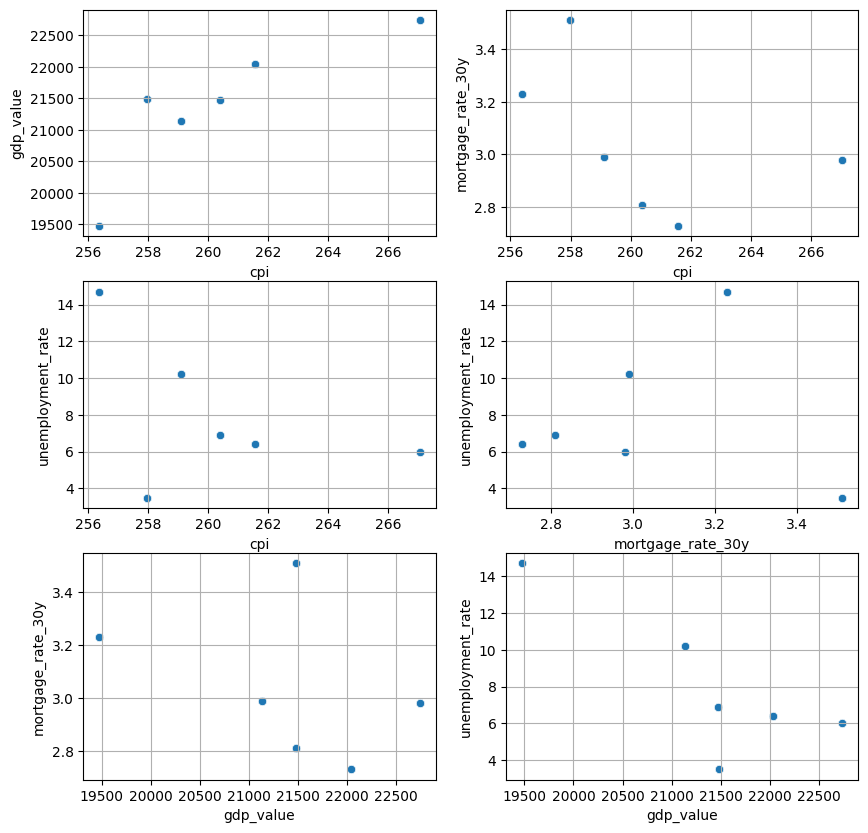

In [108]:
## Correlations between economic variables

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.ravel()

sns.scatterplot(
    data=df_agg,
    x='cpi',
    y='gdp_value',
    ax=axes[0]
)

sns.scatterplot(
    data=df_agg,
    x='cpi',
    y='mortgage_rate_30y',
    ax=axes[1]
)

sns.scatterplot(
    data=df_agg,
    x='cpi',
    y='unemployment_rate',
    ax=axes[2]
)

sns.scatterplot(
    data=df_agg,
    x='mortgage_rate_30y',
    y='unemployment_rate',
    ax=axes[3]
)

sns.scatterplot(
    data=df_agg,
    x='gdp_value',
    y='mortgage_rate_30y',
    ax=axes[4]
)

sns.scatterplot(
    data=df_agg,
    x='gdp_value',
    y='unemployment_rate',
    ax=axes[5]
)

for i in range(6):
    axes[i].grid()


plt.show()

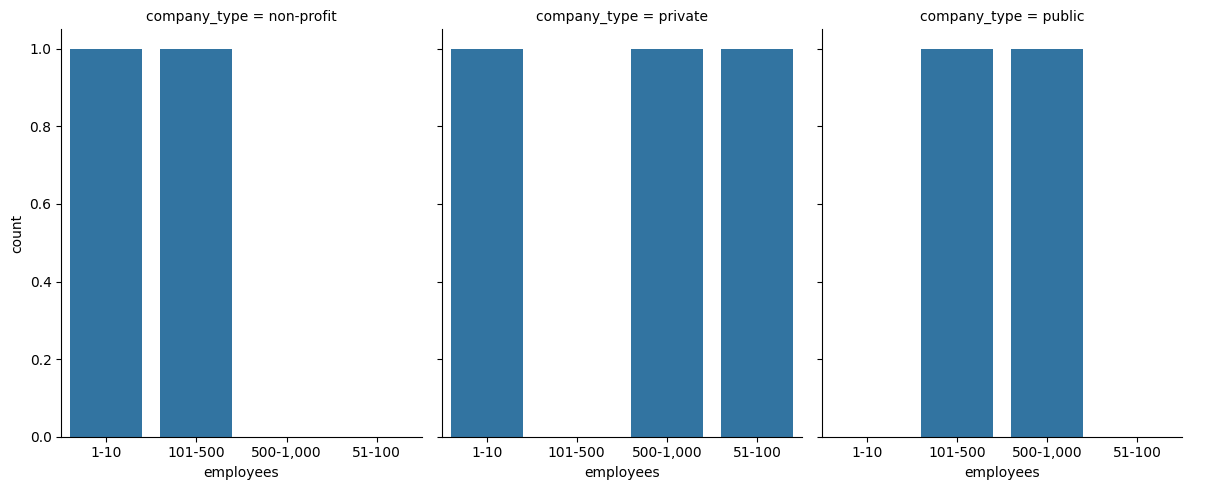

In [112]:
## Correlations between categorical variables
df_comp = df_agg[['company_type', 'employees']].drop_duplicates()

sns.catplot(
    data = df_comp,
    kind = 'count',
    x = 'employees',
    col = 'company_type',
    aspect = .8
)

In [113]:
# Chi-square test to check whether there is a relationship between size and type of the company
# Actually, there is not enough observations here to really make the test.

contingency_table = pd.crosstab(df_comp['company_type'], df_comp['employees'])
chi2, p_val, dof, expected = chi2_contingency(contingency_table)


print("--- Contingency Table ---")
print(contingency_table)
print("\n" + "="*30 + "\n")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p_val:.4f}")
print(f"Degrees of Freedom: {dof}")
print("\nExpected Frequencies Table:")
print(expected)
print("\n" + "="*30 + "\n")

--- Contingency Table ---
employees     1-10  101-500  500-1,000  51-100
company_type                                  
non-profit       1        1          0       0
private          1        0          1       1
public           0        1          1       0


Chi-Square Statistic: 4.6667
p-value: 0.5872
Degrees of Freedom: 6

Expected Frequencies Table:
[[0.57142857 0.57142857 0.57142857 0.28571429]
 [0.85714286 0.85714286 0.85714286 0.42857143]
 [0.57142857 0.57142857 0.57142857 0.28571429]]




### Analysis of Autocorrelations

<Axes: xlabel='date'>

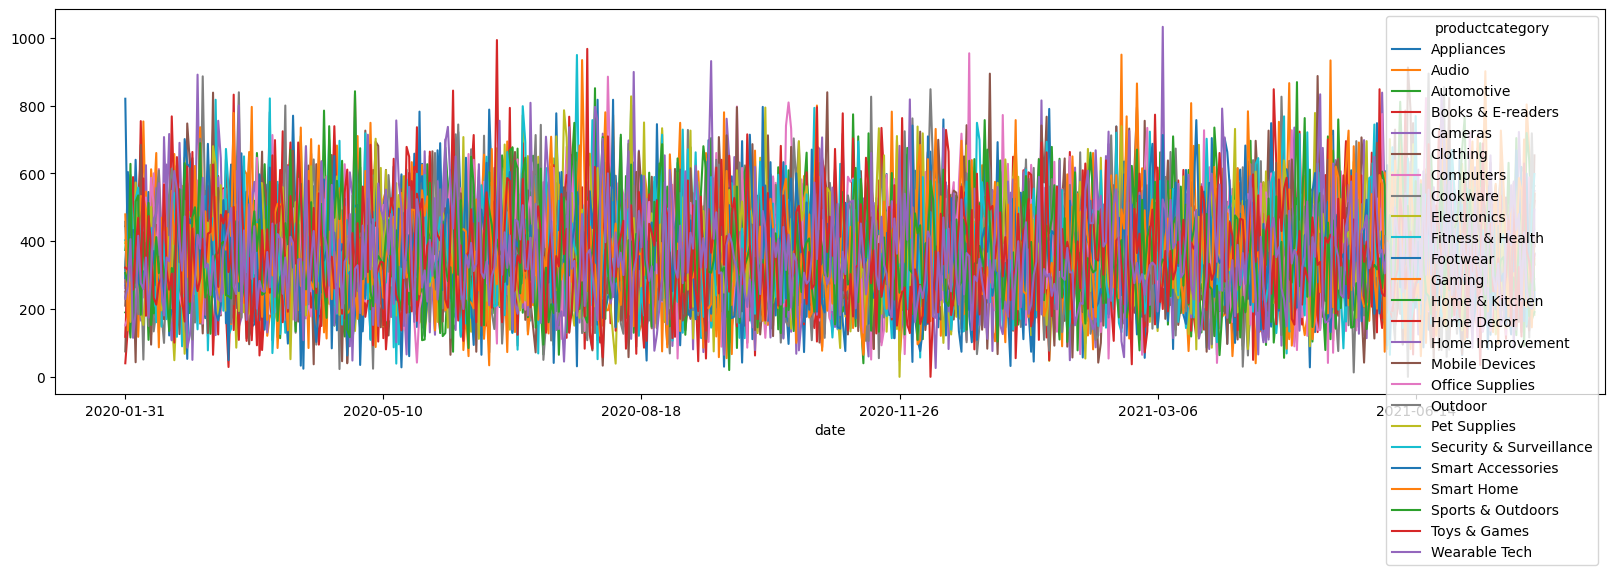

In [131]:

df_ts_products = df_agg.groupby(
    ['date', 'productcategory'],
    as_index=False
).agg(
    {
        'quantity':'sum'
    }
)

df_ts_products = df_ts_products.pivot_table(
    index = 'date',
    columns = 'productcategory',
    values = 'quantity'
).fillna(0)


df_ts_products.plot(figsize=(20, 5))

<Axes: xlabel='date'>

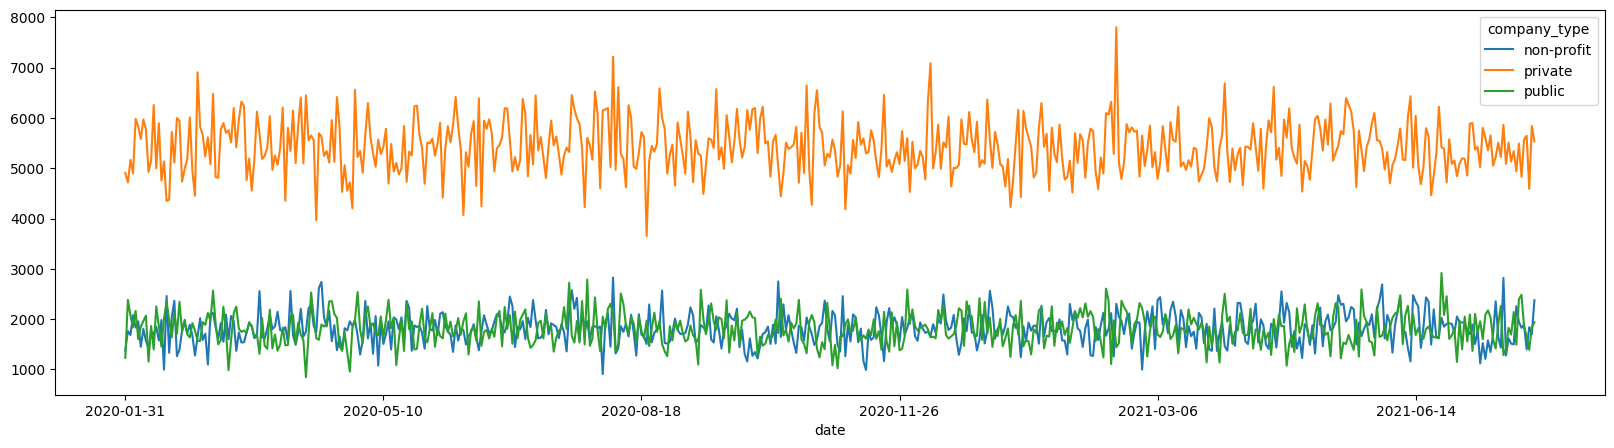

In [132]:
df_ts_company_types = df_agg.groupby(
    ['date', 'company_type'],
    as_index=False
).agg(
    {
        'quantity':'sum'
    }
)

df_ts_company_types = df_ts_company_types.pivot_table(
    index = 'date',
    columns = 'company_type',
    values = 'quantity'
).fillna(0)

df_ts_company_types.plot(figsize=(20, 5))

<Axes: xlabel='date'>

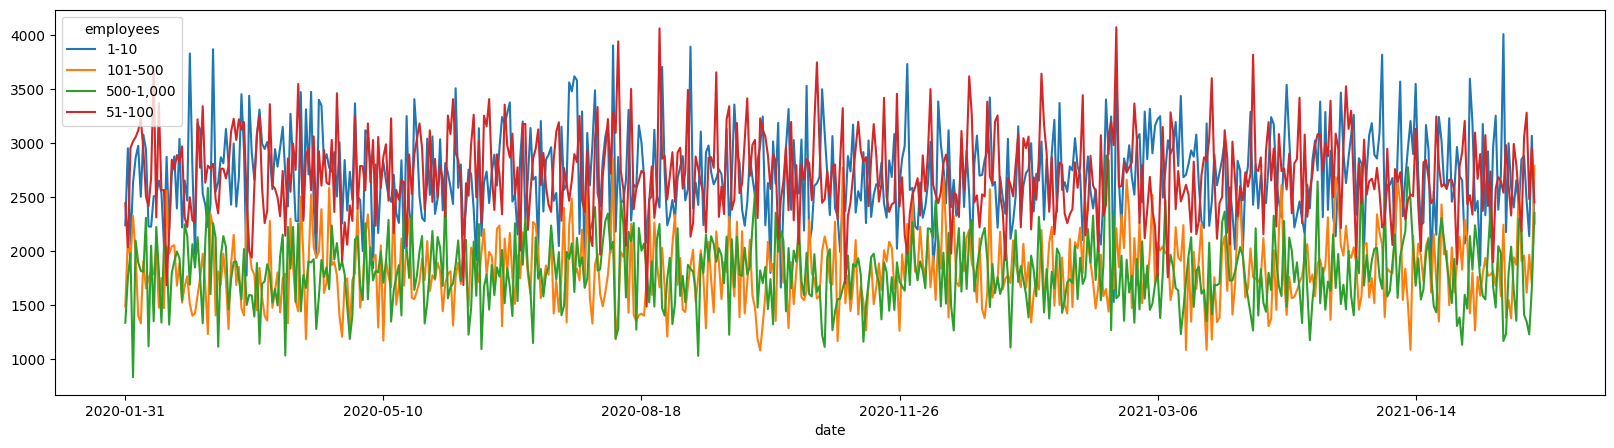

In [133]:
df_ts_employees = df_agg.groupby(
    ['date', 'employees'],
    as_index=False
).agg(
    {
        'quantity':'sum'
    }
)

df_ts_employees = df_ts_employees.pivot_table(
    index = 'date',
    columns = 'employees',
    values = 'quantity'
).fillna(0)

df_ts_employees.plot(figsize=(20, 5))

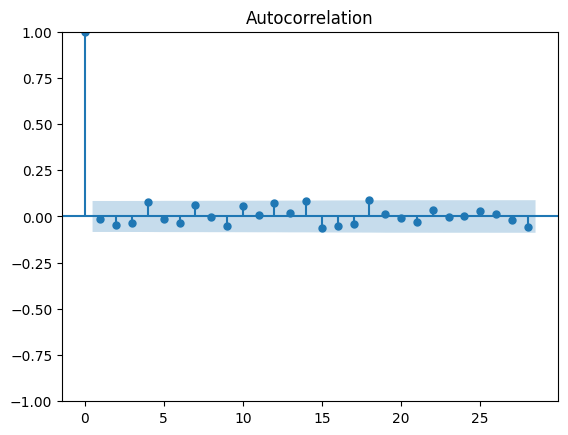

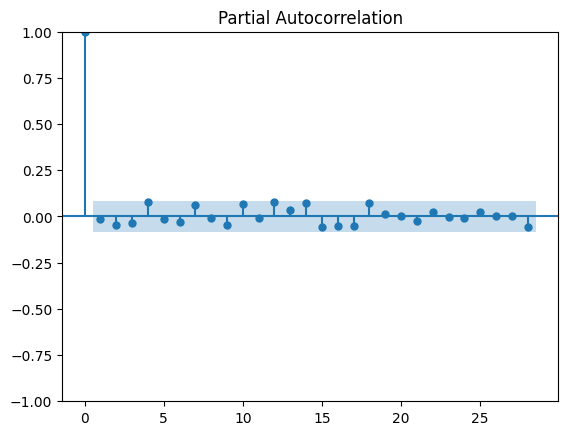

In [143]:
df_acf_pacf = df_agg.groupby(
    'date'
).agg(
    {
        'quantity':'sum'
    }
)

plot_acf(df_acf_pacf)
plot_pacf(df_acf_pacf)
plt.show()

### Analyze Outliers

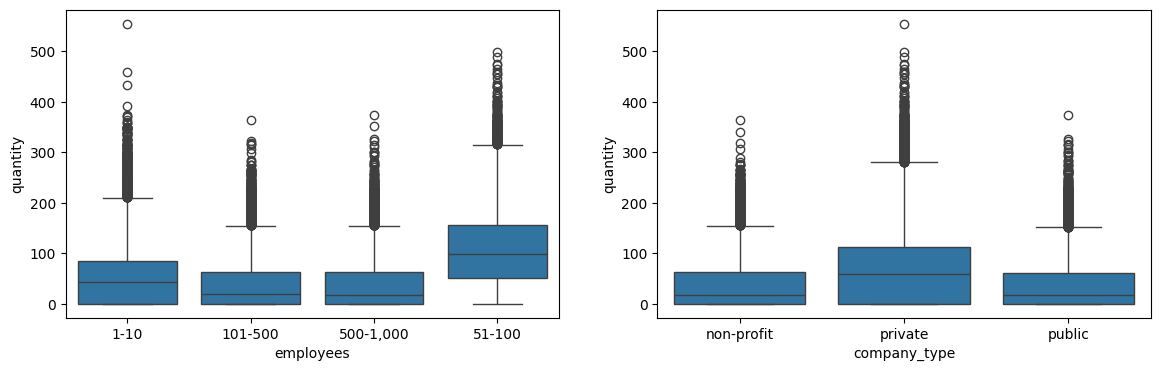

In [155]:
fig, axes = plt.subplots(1,2,figsize=(14,4))

sns.boxplot(
    data = df_agg,
    y = 'quantity',
    x = 'employees',
    ax=axes[0]
)


sns.boxplot(
    data = df_agg,
    y = 'quantity',
    x = 'company_type',
    ax=axes[1]
)

plt.show()

<Axes: xlabel='quantity', ylabel='productcategory'>

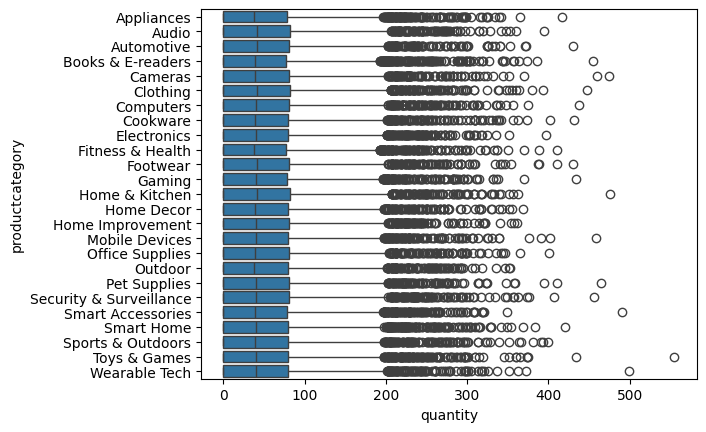

In [157]:
sns.boxplot(
    data = df_agg,
    x = 'quantity',
    y = 'productcategory'
)

<Axes: xlabel='quantity'>

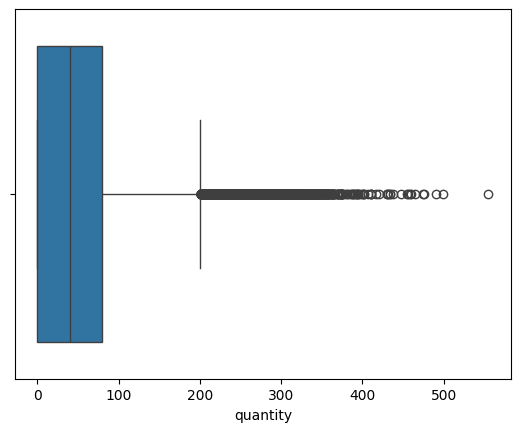

In [158]:
sns.boxplot(
    data = df_agg,
    x = 'quantity'
)

In [159]:
# What are those outliers? What is the percentage of outlier ?

x = np.quantile(df_agg['quantity'], [0, 0.25, 0.5, 0.75, 1])

q1 = x[1]
median = x[2]
q3 = x[3]
iqr = q3 -  q1

df_agg['outlier'] = np.where(
    (df_agg['quantity'] > q3 + 1.5*iqr) |
    (df_agg['quantity'] < q1 - 1.5*iqr),
    1, 0
) 

outliers = df_agg[df_agg['outlier'] == 1]['date'].count()
rows = df_agg['date'].count()

print(f'{outliers} Outliers found --> {outliers/rows * 100} % of total data')

df_agg[df_agg['outlier'] == 1].head(10)

2737 Outliers found --> 2.859232175502742 % of total data


,date,productcategory,company_type,employees,quantity,unemployment_rate,gdp_value,mortgage_rate_30y,cpi,outlier
2,2020-01-31,Appliances,private,1-10,283.0,3.5,21481.367,3.51,257.971,1
4,2020-01-31,Appliances,private,51-100,325.0,3.5,21481.367,3.51,257.971,1
137,2020-01-31,Security & Surveillance,private,51-100,295.0,3.5,21481.367,3.51,257.971,1
151,2020-01-31,Smart Home,private,51-100,202.0,3.5,21481.367,3.51,257.971,1
233,2020-02-01,Electronics,private,1-10,246.0,3.5,21481.367,3.51,257.971,1
263,2020-02-01,Home & Kitchen,private,51-100,236.0,3.5,21481.367,3.51,257.971,1
296,2020-02-01,Outdoor,private,1-10,253.0,3.5,21481.367,3.51,257.971,1
320,2020-02-01,Smart Accessories,public,101-500,208.0,3.5,21481.367,3.51,257.971,1
339,2020-02-01,Toys & Games,private,"500-1,000",220.0,3.5,21481.367,3.51,257.971,1
361,2020-02-02,Audio,private,51-100,297.0,3.5,21481.367,3.51,257.971,1


<Axes: ylabel='log_quantity'>

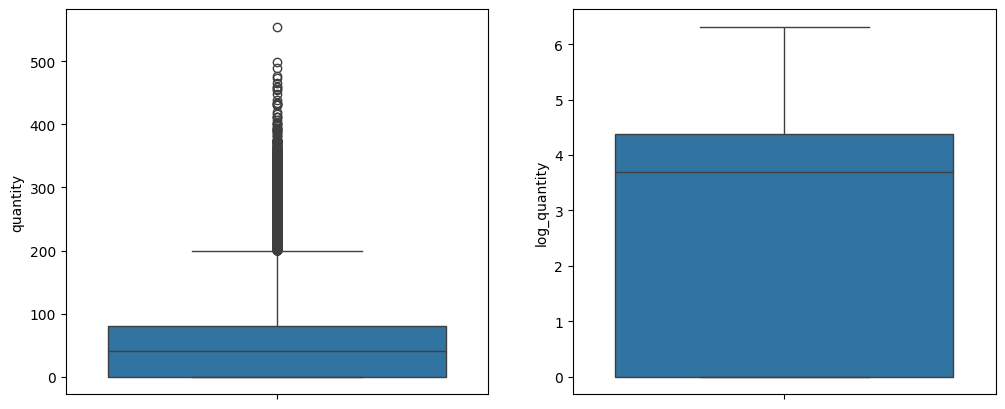

In [161]:
# Instead of replacing outliers we can try to log the quantity to make it more normally distributed
df_agg['log_quantity'] = df_agg['quantity'].apply(
    lambda x: np.log(x) if x > 0 else 0
)

fig, axes = plt.subplots(1,2,figsize=(12,5))
sns.boxplot(
    data = df_agg,
    y = 'quantity',
    ax=axes[0]
)
sns.boxplot(
    data = df_agg,
    y = 'log_quantity',
    ax=axes[1]
)

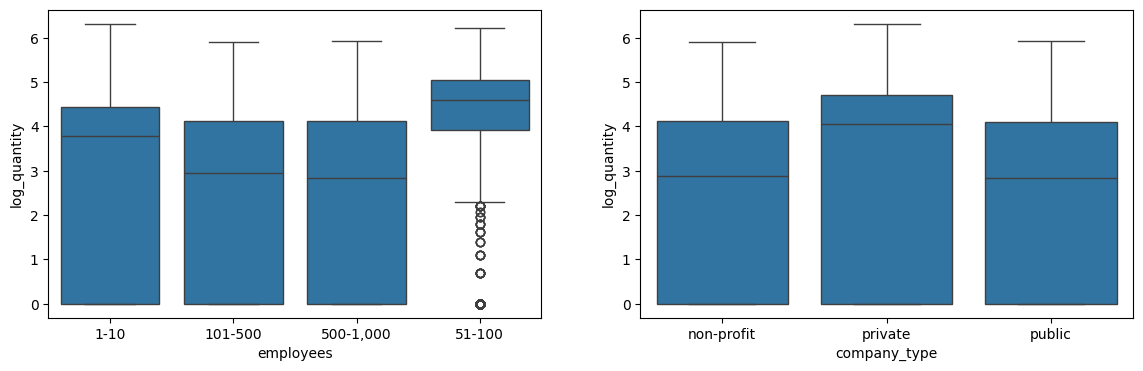

In [162]:
fig, axes = plt.subplots(1,2,figsize=(14,4))

sns.boxplot(
    data = df_agg,
    y = 'log_quantity',
    x = 'employees',
    ax=axes[0]
)


sns.boxplot(
    data = df_agg,
    y = 'log_quantity',
    x = 'company_type',
    ax=axes[1]
)

plt.show()


### OLS to remove Economic Correlations

In [187]:
# We first set up target value as the next day
df_agg["quantity_shifted"] = (
    df_agg.sort_values(["company_type", "employees", "productcategory", "date"], 
                      ascending=[True, True, True, True])
      .groupby(["company_type", "employees", "productcategory"])["quantity"]
      .shift(-1)
)

df_agg["log_quantity_shifted"] = df_agg["quantity_shifted"].apply(
    lambda x: np.log(x) if x>0 else 0
)

df_agg = df_agg.fillna(0)

df_agg.sort_values(["company_type", "employees", "productcategory", "date"]).head(20)

,date,productcategory,company_type,employees,quantity,unemployment_rate,gdp_value,mortgage_rate_30y,cpi,outlier,log_quantity,quantity_shifted,log_quantity_shifted
0,2020-01-31,Appliances,non-profit,1-10,12.0,3.5,21481.367,3.51,257.971,0,2.484907,64.0,4.158883
175,2020-02-01,Appliances,non-profit,1-10,64.0,3.5,21481.367,3.51,257.971,0,4.158883,65.0,4.174387
350,2020-02-02,Appliances,non-profit,1-10,65.0,3.5,21481.367,3.51,257.971,0,4.174387,43.0,3.761200
525,2020-02-03,Appliances,non-profit,1-10,43.0,3.5,21481.367,3.51,257.971,0,3.761200,0.0,0.000000
700,2020-02-04,Appliances,non-profit,1-10,0.0,3.5,21481.367,3.51,257.971,0,0.000000,143.0,4.962845
875,2020-02-05,Appliances,non-profit,1-10,143.0,3.5,21481.367,3.51,257.971,0,4.962845,0.0,0.000000
1050,2020-02-06,Appliances,non-profit,1-10,0.0,3.5,21481.367,3.51,257.971,0,0.000000,0.0,0.000000
1225,2020-02-07,Appliances,non-profit,1-10,0.0,3.5,21481.367,3.51,257.971,0,0.000000,0.0,0.000000
1400,2020-02-08,Appliances,non-profit,1-10,0.0,3.5,21481.367,3.51,257.971,0,0.000000,0.0,0.000000
1575,2020-02-09,Appliances,non-profit,1-10,0.0,3.5,21481.367,3.51,257.971,0,0.000000,20.0,2.995732


### Save Data

In [188]:
df_agg.to_csv(os.path.abspath('../data/silver/joined_purchases_prep.csv'), index=False)